In [1]:
#Импортируем бибилиотеки
import pandas as pd
from scipy.stats import ttest_ind
import numpy as np

In [2]:
# Импортируем файл
df = pd.read_excel(r'C:\Users\79053\OneDrive\Рабочий стол\аналитик данных\дипломная_работа\датасет.xlsx')

# Смотрим таблицу
df.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-07-17 21:48:15.896
1,100242,191056.0,4151.0,2022-07-07 03:09:39.699
2,100249,200049.0,5688.0,2022-07-29 13:25:59.976
3,100258,206161.0,4330.0,2022-08-15 22:55:02.538
4,100267,190945.0,5488.0,2022-07-05 19:46:47.174


In [3]:
# Загружаем все листы в словарь
all_sheets = pd.read_excel('датасет.xlsx', sheet_name=None)

# Посмотреть имена всех листов (таблиц)
print(all_sheets.keys())


dict_keys(['Данные', 'Clients', 'Region_dict'])


In [4]:
# Записываем конкретный лист в отдельную переменную
data=all_sheets['Данные']
data.head()


,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-07-17 21:48:15.896
1,100242,191056.0,4151.0,2022-07-07 03:09:39.699
2,100249,200049.0,5688.0,2022-07-29 13:25:59.976
3,100258,206161.0,4330.0,2022-08-15 22:55:02.538
4,100267,190945.0,5488.0,2022-07-05 19:46:47.174


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 37989 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     37989 non-null  int64         
 1   id_client    37401 non-null  float64       
 2   amt_payment  35845 non-null  float64       
 3   dtime_pay    35560 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1)
memory usage: 1.2 MB


In [6]:
#Смотрим на пропуски в данных
data.isna().sum()

id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64

In [7]:
#Узнаем какой процент пропусков имеется на всю таблицу
data.isna().mean().mean() * 100

np.float64(3.396377898865461)

In [8]:
#Посмотрим на пропуски
data[data.isna().any(axis=1)]


,id_order,id_client,amt_payment,dtime_pay
8,100285,195780.0,NaN,NaT
49,100471,203089.0,NaN,NaT
61,100524,NaN,NaN,NaT
76,100594,183063.0,3338.0,NaT
87,100645,NaN,NaN,NaT
...,...,...,...,...
37961,297452,191024.0,NaN,NaT
37969,297488,202717.0,NaN,NaT
37970,297490,NaN,NaN,NaT
37973,297502,201726.0,NaN,NaT


Провела анализ пропусков. Делаем выводы, оставлять или удалять пропуски.

id_order: 0 пропусков.У каждого заказа есть свой номер.

id_client: 588 пропусков (37989 - 37401). У нас есть транзакции, где не указан клиент. Такое бывает, если покупка совершалась «в 1 клик» без регистрации, или это была гостевая покупка, или произошел технический сбой.Решение: Так как тут есть деньги (amt_payment), удалять эти строки нельзя. Мы сохраним их, присвоив им вымышленный ID клиента (например, 0 или -1), чтобы они обозначали «Анонимный покупатель».

amt_payment: 2 144 пропуска (37989 - 35845).Что это значит: Это те самые «брошенные корзины» или неоплаченные заказы, которые мы обсуждали.Решение: Сохраняем, заменяя пропуски на 0.

dtime_pay (35 560 non-null): 2 429 пропусков (37989 - 35560).Что это значит: Время оплаты не зафиксировано.Решение: Сохраняем, заменяя на дату-заглушку (1900-01-01).

In [9]:
# 1. Создаем чистую копию таблицы
data_cl = df.copy()

# 2. Спасаем пропущенные ID клиентов: ставим -1 (будет означать "Аноним/Ошибка")
data_cl['id_client'] = data_cl['id_client'].fillna(-1)

# 3. Спасаем пропущенные суммы: ставим 0
data_cl['amt_payment'] = data_cl['amt_payment'].fillna(0.0)

# 4. Спасаем пропущенные даты: ставим заглушку 1900-01-01
data_cl['dtime_pay'] = data_cl['dtime_pay'].fillna(pd.Timestamp('1900-01-01'))

# 5. Возвращаем id_client красивый целочисленный вид (сейчас он float64 из-за пропусков)
data_cl['id_client'] = data_cl['id_client'].astype(int)

# Проверяем, что пропусков больше нет
print(data_cl.info())


<class 'pandas.DataFrame'>
RangeIndex: 37989 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     37989 non-null  int64         
 1   id_client    37989 non-null  int64         
 2   amt_payment  37989 non-null  float64       
 3   dtime_pay    37989 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 1.2 MB
None


In [10]:
data_cl.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569,5373.0,2022-07-17 21:48:15.896
1,100242,191056,4151.0,2022-07-07 03:09:39.699
2,100249,200049,5688.0,2022-07-29 13:25:59.976
3,100258,206161,4330.0,2022-08-15 22:55:02.538
4,100267,190945,5488.0,2022-07-05 19:46:47.174


Проводим анализ на пропуски в таблице 'Clients'

In [11]:
# Записываем конкретный лист в отдельную переменную
clients = all_sheets['Clients']
clients.head()


,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015


In [12]:
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55605 non-null  int64         
 1   dtime_ad          55356 non-null  datetime64[us]
 2   nflag_test        55605 non-null  int64         
 3   id_trading_point  55605 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 1.7 MB


In [13]:
#Смотрим на пропуски в данных
clients.isna().sum()


id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
dtype: int64

In [14]:
#Узнаем какой процент пропусков имеется на всю таблицу
clients.isna().mean().mean()*100

np.float64(0.11195036417588347)

dtime_ad: Всего 249 пропусков. Нам важно оставить количество в тестовой и контрольной группе. Поэтому мы на пропуски поставим дату-заглушку '1900-01-01'

In [15]:
# Создаем чистую копию и заполняем NaT заглушкой
clients_cl = clients.copy()
clients_cl['dtime_ad'] = clients_cl['dtime_ad'].fillna(pd.Timestamp('1900-01-01'))

clients_cl.info()

<class 'pandas.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55605 non-null  int64         
 1   dtime_ad          55605 non-null  datetime64[us]
 2   nflag_test        55605 non-null  int64         
 3   id_trading_point  55605 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 1.7 MB


Проводим анализ на пропуски в таблице 'Region_dict'

In [16]:
# Записываем конкретный лист в отдельную переменную
region_dict = all_sheets['Region_dict']
region_dict.head()

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир


In [17]:
region_dict.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id_trading_point  66 non-null     int64
 1   city              66 non-null     str  
dtypes: int64(1), str(1)
memory usage: 1.2 KB


Все три таблицы изучены, таблицы проверены на наличие пустых значений и исправлены.


Теперь посмотрим на количество торговых точек в каждом городе и визуализируем их с помощью столбчатой диаграммы.

In [18]:
cnt_trading_point = region_dict.groupby(['city']).agg({'id_trading_point': 'count'}).reset_index()
cnt_trading_point.head(50)

# Группируем по городам и считаем количество торговых точек
cnt_stores_by_city = region_dict.groupby('city').agg({'id_trading_point':'nunique'}).reset_index()

# Переименовываем колонки 
cnt_stores_by_city.columns = ['city','count_stores']

# Обязательно сортируем по убыванию, чтобы график смотрелся аккуратно и понятно
cnt_stores_by_city = cnt_stores_by_city.sort_values(by = 'count_stores', ascending=False)

cnt_stores_by_city

,city,count_stores
7,Москва,11
15,Санкт-Петербург,11
4,Казань,6
10,Новосибирск,6
6,Красноярск,5
14,Самара,4
5,Краснодар,4
16,Саратов,2
18,Сочи,2
8,Мурманск,2


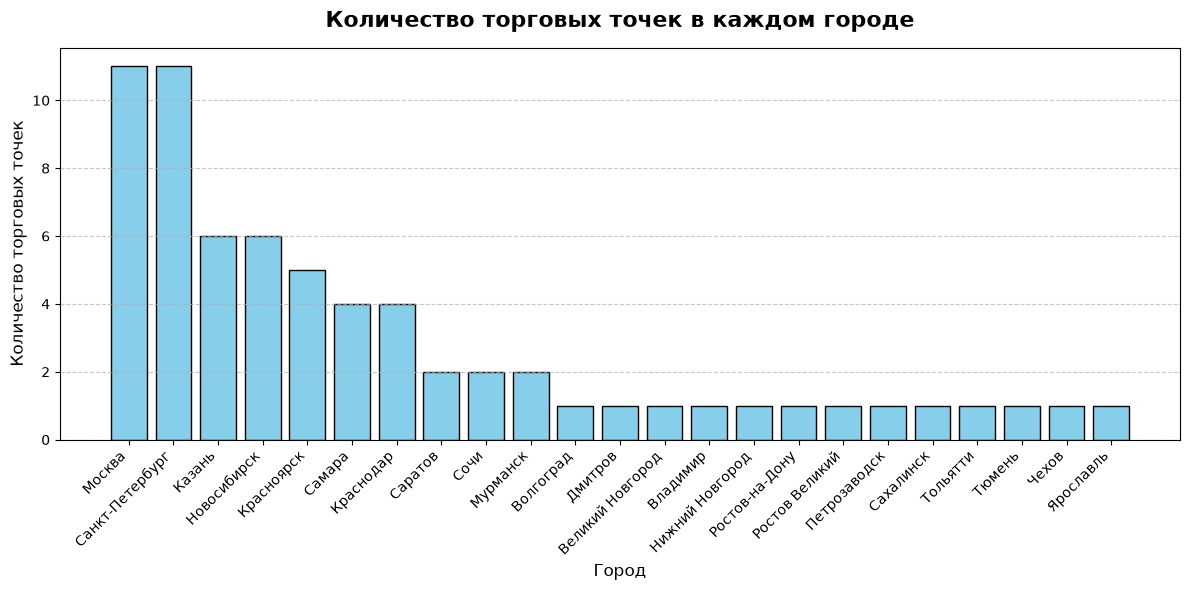

In [19]:
# Строим столбчатую диаграмму
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6)) # Задаем размер графика

# Создаем столбцы: по оси X — города, по оси Y — количество точек
plt.bar(cnt_stores_by_city['city'], cnt_stores_by_city['count_stores'],color='skyblue', edgecolor='black')

# Добавляем подписи и красивое оформление
plt.title('Количество торговых точек в каждом городе', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Город', fontsize=12)
plt.ylabel('Количество торговых точек', fontsize=12)

# Поворачиваем названия городов на 45 градусов, чтобы они не накладывались друг на друга
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7) # Добавляем легкую сетку для удобства чтения
plt.tight_layout() # Автоматически выравнивает элементы графика, чтобы ничего не обрезалось

# Выводим график на экран
plt.show()

Теперь объединяем таблицы

In [20]:
data_cl.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569,5373.0,2022-07-17 21:48:15.896
1,100242,191056,4151.0,2022-07-07 03:09:39.699
2,100249,200049,5688.0,2022-07-29 13:25:59.976
3,100258,206161,4330.0,2022-08-15 22:55:02.538
4,100267,190945,5488.0,2022-07-05 19:46:47.174


In [21]:
#Группируем таблицу платежей и считаем сумму платежей
client_payments = data_cl.groupby('id_client').agg({'amt_payment':'sum'}).reset_index()

#Переименовываем колонки
client_payments.columns = ['id_client','total_payment']

#Сортируем клиентов по убыванию их платежей
client_payments = client_payments.sort_values(by='total_payment', ascending=False)

client_payments.head(10)

,id_client,total_payment
15965,195273,43083.0
23635,203282,42222.0
1723,180362,38664.0
15544,194825,36645.0
12902,192062,36310.0
28817,208695,35363.0
13384,192568,35318.0
2250,180912,35136.0
10037,189065,33761.0
2428,181099,33512.0


In [22]:
# 1. Объединяем таблицы по колонке 'id_client'
# Клиентская таблица clients_cl стоит слева, чтобы сохранить абсолютно всех её пользователей
client_total = clients_cl.merge(client_payments, on='id_client', how='left')

# 2. Заменяем NaN на 0 для тех клиентов, которые участвовали в тесте, но ничего не купили
client_total['total_payment'] = client_total['total_payment'].fillna(0)

# 3. Проверяем, что количество строк совпадает с исходной клиентской таблицей clients_cl
print(f"Строк в клиентской таблице (clients_cl): {len(clients_cl)}")
print(f"Строк в итоговой таблице (client_total): {len(client_total)}")

# Выводим первые 5 строк объединенного результата
client_total.head()


Строк в клиентской таблице (clients_cl): 55605
Строк в итоговой таблице (client_total): 55605


,id_client,dtime_ad,nflag_test,id_trading_point,total_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0
1,193942,1900-01-01 00:00:00.000,0,13,4144.0
2,226069,2022-07-11 16:28:38.511,1,54,0.0
3,183981,2022-06-16 12:23:59.289,1,991,6322.0
4,322530,2022-07-08 08:56:08.714,0,1015,0.0


In [23]:
# 1. Объединяем таблицу клиентов client_total с таблицей регионов region_dict
# Связываем их по общей колонке 'id_trading_point'
client_total = client_total.merge(region_dict, on='id_trading_point', how='left')

# 2. Проверяем, что количество строк не изменилось, но появилась новая колонка 'city'
print(f"Количество строк в таблице: {len(client_total)}")

# Выводим первые 5 строк, чтобы увидеть результат с городами
client_total.head()


Количество строк в таблице: 55605


,id_client,dtime_ad,nflag_test,id_trading_point,total_payment,city
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск
1,193942,1900-01-01 00:00:00.000,0,13,4144.0,Нижний Новгород
2,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск
3,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань
4,322530,2022-07-08 08:56:08.714,0,1015,0.0,Краснодар


In [24]:
import numpy as np

# Создаем новую колонку с признаком: оплатил = 1, нет оплаты = 0
client_total['nflag_payment'] = np.where(client_total['total_payment'] > 0, 1, 0)

# Проверяем результат: выведем несколько строк, где есть и нули, и покупки
client_total[['id_client', 'total_payment', 'nflag_payment']].head(10)


,id_client,total_payment,nflag_payment
0,180844,5349.0,1
1,193942,4144.0,1
2,226069,0.0,0
3,183981,6322.0,1
4,322530,0.0,0
5,254313,0.0,0
6,195818,4021.0,1
7,267165,0.0,0
8,246645,0.0,0
9,274394,0.0,0


In [25]:
client_total.head()

,id_client,dtime_ad,nflag_test,id_trading_point,total_payment,city,nflag_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,193942,1900-01-01 00:00:00.000,0,13,4144.0,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
4,322530,2022-07-08 08:56:08.714,0,1015,0.0,Краснодар,0


Автоматизация статистических вычислений.

In [26]:
#Убедимся, что пользователь относится только к одной группе.
client_total.groupby('id_client').agg(cnt_user = ('id_client', 'count'))['cnt_user'].unique()


array([1])

In [27]:
# Создаю функцию test_calc, которая будет вычислять значение t-критерия (критерия Стьюдента) и p_value 
# для сравнения средних и с помощью функции print выводить сообщение о том, 
# существует ли разница между средними (на основании p_value).
from scipy.stats import ttest_ind

def test_calc(r1, r2, alpha=0.05):
    # Вычисляем t-критерий и p-value
    t_stat, p_value = ttest_ind(r1, r2)
    
    # Выводим результаты
    print(f"T-Statistic: {t_stat}")
    print(f"P-Value: {p_value}")
    
    # Проверяем, существует ли статистически значимая разница между средними
    if p_value < alpha:
        print("Существует статистически значимая разница между средними.")
    else:
        print("Статистически значимой разницы между средними нет.")

In [28]:
# Создаю функцию mann_whitney_func, которая будет рассчитывать значение критерия Манна Уитни и p_value для сравнения распределений 
# и с помощью функции print выводить сообщение о том, существует ли разница между средними (на основании p_value).

from scipy.stats import mannwhitneyu

def mann_whitney_func(r1, r2, alpha=0.05):
    
    # Вычисляем статистику Манна-Уитни и p-value
    stat, p_value = mannwhitneyu(r1, r2)
    
    # Выводим результаты
    print(f"Mann-Whitney U Statistic: {stat}")
    print(f"P-Value: {p_value}")
    
    # Проверяем, существует ли статистически значимая разница между распределениями
    if p_value < alpha:
        print("Существует статистически значимая разница между средними.")
    else:
        print("Статистически значимой разницы между средними нет.")

Точки с нулевой выручкой в обеих группах.

In [29]:
list_no_payment = [] 

# Считаем суммы оплат для всех магазинов
grouped = client_total.groupby(['id_trading_point', 'nflag_test'])['total_payment'].sum()

# Получаем список всех магазинов
unique_shops = client_total['id_trading_point'].unique() 

# Перебираем магазины по одному
for shop in unique_shops:
    control_sum = grouped.get((shop, 0), 0) # сумма контроля
    test_sum = grouped.get((shop, 1), 0)    # сумма теста
    
    # Проверка
    if control_sum == 0 and test_sum == 0:
        list_no_payment.append(shop)

  


print(list_no_payment)

[np.int64(26), np.int64(7), np.int64(4), np.int64(1)]


In [30]:
# 1. Создаем пустой список для пустующих групп
list_empty_groups = []

# 2. Считаем количество клиентов в каждой группе для каждой точки
grouped_counts = client_total.groupby(['id_trading_point', 'nflag_test'])['id_client'].count()

# 3. Твой цикл, который проверяет условия и заполняет список
for shop in unique_shops:
    control_count = grouped_counts.get((shop, 0), 0)
    test_count = grouped_counts.get((shop, 1), 0)
    
    if control_count == 0 or test_count == 0:
        list_empty_groups.append(shop)

print(list_empty_groups)

[np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(228), np.int64(603), np.int64(810), np.int64(800)]


Расчет общих результатов A/B-теста.

In [31]:
# Объединяем списки
bad_shops = list(set(list_no_payment + list_empty_groups))
# Оставляем только хорошие точки
client_total_clean = client_total[~client_total['id_trading_point'].isin(bad_shops)]

print("Было строк:", len(client_total))
print("Стало строк:", len(client_total_clean))


Было строк: 55605
Стало строк: 46927


In [32]:
client_total_clean.head()

,id_client,dtime_ad,nflag_test,id_trading_point,total_payment,city,nflag_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,193942,1900-01-01 00:00:00.000,0,13,4144.0,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
5,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:
#Разделим пользователей на группы
control = client_total_clean[client_total_clean['nflag_test']== 0]
test = client_total_clean[client_total_clean['nflag_test']==1]

print(len(control))
print(len(test))

23659
23268


In [35]:
test.head()

,id_client,dtime_ad,nflag_test,id_trading_point,total_payment,city,nflag_payment
2,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
5,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0
6,195818,2022-07-16 01:30:59.088,1,2652,4021.0,Москва,1
9,274394,2022-06-25 00:46:07.492,1,2652,0.0,Москва,0


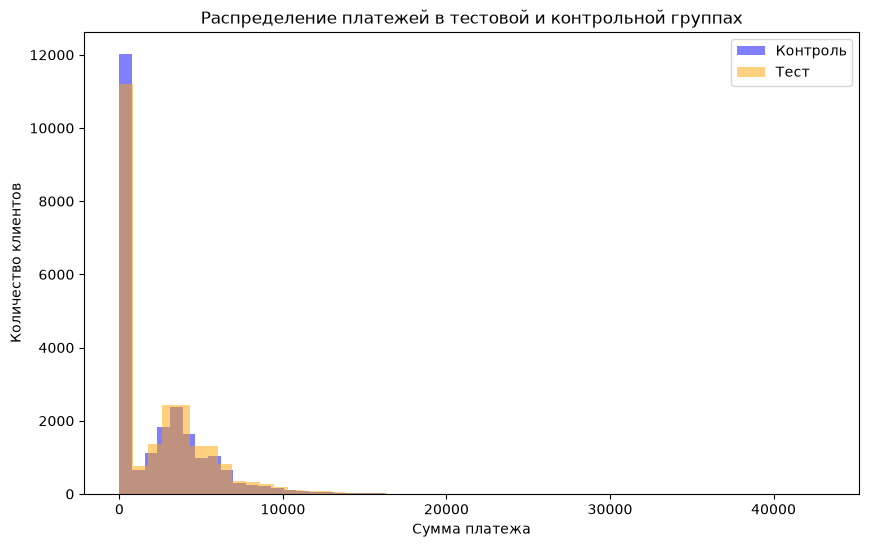

In [36]:
# 3. Настраиваем размер графика
plt.figure(figsize=(10, 6))

# 4. Строим гистограмму для контроля (alpha делает график прозрачным, чтобы группы не перекрывали друг друга)
plt.hist(control['total_payment'], alpha=0.5, label='Контроль', color='blue', bins=50)

# 5. Строим гистограмму для теста поверх контроля
plt.hist(test['total_payment'], alpha=0.5, label='Тест', color='orange', bins=50)

# 6. Оформляем график
plt.title('Распределение платежей в тестовой и контрольной группах')
plt.xlabel('Сумма платежа')
plt.ylabel('Количество клиентов')

# 7. Включаем отображение легенды (окошко с названиями "Контроль" и "Тест")
plt.legend()

# 8. Выводим готовый рисунок на экран
plt.show()

In [37]:
client_total_clean['total_payment'].describe()

count    46927.000000
mean      2288.225776
std       2951.450145
min          0.000000
25%          0.000000
50%        996.000000
75%       3888.000000
max      43083.000000
Name: total_payment, dtype: float64

In [38]:
#Считаем зону выбросов
Q1 = np.percentile(client_total_clean['total_payment'],25)
Q3 = np.percentile(client_total_clean['total_payment'],75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

-5832.0
9720.0


In [39]:
#Оставляем платежи которые, меньше 9720 руб.
df_clean = client_total_clean.loc[client_total_clean['total_payment']<upper_bound]
df_clean

,id_client,dtime_ad,nflag_test,id_trading_point,total_payment,city,nflag_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,193942,1900-01-01 00:00:00.000,0,13,4144.0,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
5,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0
...,...,...,...,...,...,...,...
55598,260405,2022-08-15 02:47:58.960,0,576,0.0,Санкт-Петербург,0
55599,188702,2022-06-28 06:16:25.664,0,453,1323.0,Санкт-Петербург,1
55601,244069,2022-08-08 00:12:31.319,1,991,0.0,Казань,0
55602,189084,2022-06-29 04:34:42.610,1,439,7146.0,Казань,1


In [40]:
df_clean['total_payment'].describe()

count    45844.000000
mean      2042.042143
std       2434.311989
min          0.000000
25%          0.000000
50%        606.500000
75%       3756.250000
max       9718.000000
Name: total_payment, dtype: float64

In [41]:
#Разделим пользователей на группы
control = df_clean[df_clean['nflag_test']== 0]
test = df_clean[df_clean['nflag_test']==1]

print(len(control))
print(len(test))

23158
22686


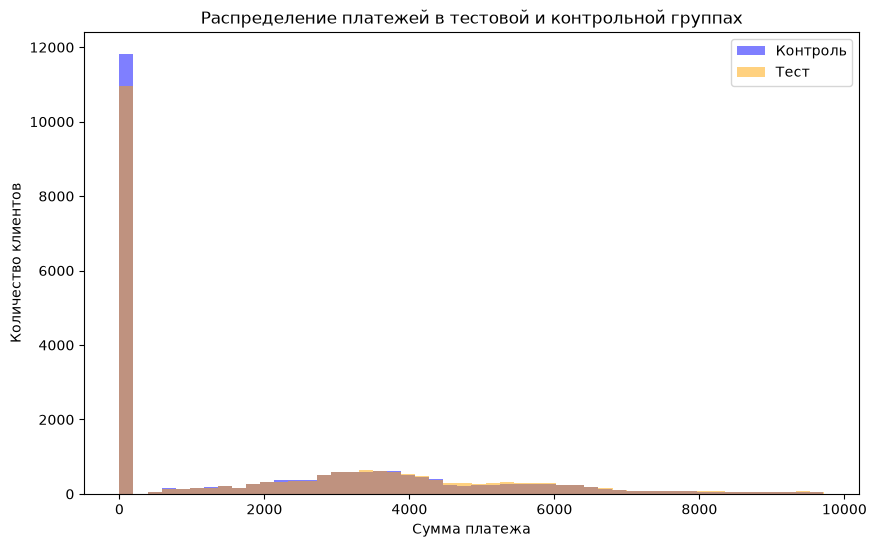

In [42]:
# 3. Настраиваем размер графика
plt.figure(figsize=(10, 6))

# 4. Строим гистограмму для контроля (alpha делает график прозрачным, чтобы группы не перекрывали друг друга)
plt.hist(control['total_payment'], alpha=0.5, label='Контроль', color='blue', bins=50)

# 5. Строим гистограмму для теста поверх контроля
plt.hist(test['total_payment'], alpha=0.5, label='Тест', color='orange', bins=50)

# 6. Оформляем график
plt.title('Распределение платежей в тестовой и контрольной группах')
plt.xlabel('Сумма платежа')
plt.ylabel('Количество клиентов')

# 7. Включаем отображение легенды (окошко с названиями "Контроль" и "Тест")
plt.legend()

# 8. Выводим готовый рисунок на экран
plt.show()

In [43]:
# Применяем функцию test_calc для платежей
test_calc(control['total_payment'], test['total_payment'])

T-Statistic: -6.939526949183347
P-Value: 3.986261094447101e-12
Существует статистически значимая разница между средними.


In [44]:
# Применяем функцию test_calc для конверсии
control_conversion = df_clean [df_clean['nflag_test'] == 0]['nflag_payment']
test_conversion = df_clean[df_clean['nflag_test'] == 1]['nflag_payment']
test_calc(control_conversion, test_conversion)

T-Statistic: -5.835595333225774
P-Value: 5.395851630138959e-09
Существует статистически значимая разница между средними.


In [45]:
# Применяем функцию mann_whitney_func для платежей
mann_whitney_func(control['total_payment'], test['total_payment'])

Mann-Whitney U Statistic: 253572202.5
P-Value: 6.675198605464142e-12
Существует статистически значимая разница между средними.


Главный итог: Тест однозначно успешный. Мы зафиксировали мощный и чистый рост платежей в тестовой группе. Изменения можно уверенно раскатывать на 100% пользователей.

Данные платежей всегда «капризные» (в них много нулей и длинный хвост крупных чеков), поэтому мы перестраховались и проверили метрики двумя разными методами. Оба показали феноменальный результат:Средний чек и выручка выросли (T-test)Наш t-test показал железобетонную значимость (p-value ≈ 4e-12). 
Шанс того, что этот прирост случайность или просто «шум» в данных, равен нулю.
Чтобы убедиться, что средний чек не вырос просто из-за пары случайных «богатых» клиентов, мы запустили непараметрический тест распределений. Он полностью подтвердил (p-value ≈ 6.7e-12): пользователи в тесте стали платить больше массово. 
График распределения наглядно это показывает — сильный сдвиг оранжевой зоны в сторону крупных покупок.
Вывод: Тестируемая фича напрямую влияет на монетизацию. Мы не просто получили случайный всплеск выручки, а системно изменили покупательское поведение пользователей в лучшую сторону.Продукт готов к полноценному релизу.

Сегментация результатов A/B-теста.

Москва.

In [46]:
df_clean.head()

,id_client,dtime_ad,nflag_test,id_trading_point,total_payment,city,nflag_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,193942,1900-01-01 00:00:00.000,0,13,4144.0,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
5,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0


In [47]:
#Разделим пользователей на группы по городу Москва
control_msk = df_clean[(df_clean['nflag_test']== 0) & (df_clean['city']=='Москва')]
test_msk = df_clean[(df_clean['nflag_test']==1) & (df_clean['city']=='Москва')]

print(len(control_msk))
print(len(test_msk))


6131
6009


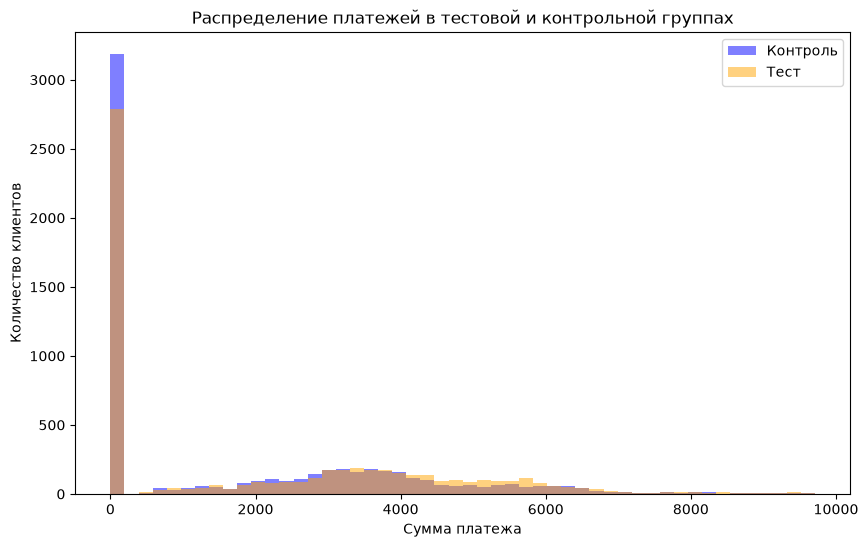

In [48]:
# Гистограмма платежей по Москве.

# Размер графика
plt.figure(figsize=(10, 6))

# Строим гистограмму для контроля
plt.hist(control_msk['total_payment'], alpha=0.5, label='Контроль', color='blue', bins=50)

# Строим гистограмму для теста поверх контроля
plt.hist(test_msk['total_payment'], alpha=0.5, label='Тест', color='orange', bins=50)

# Оформляем график
plt.title('Распределение платежей в тестовой и контрольной группах')
plt.xlabel('Сумма платежа')
plt.ylabel('Количество клиентов')

# Включаем отображение легенды (окошко с названиями "Контроль" и "Тест")
plt.legend()

# Выводим готовый рисунок на экран
plt.show()

In [49]:
# Применяем функцию test_calc для платежей по Москве
test_calc(control_msk['total_payment'], test_msk['total_payment'])

T-Statistic: -8.031168084184038
P-Value: 1.0543188961688707e-15
Существует статистически значимая разница между средними.


In [50]:
# Применяем функцию test_calc для конверсии по Москве
control_conversion_msk = df_clean [(df_clean['nflag_test'] == 0) & (df_clean['city'] =='Москва')]['nflag_payment']
test_conversion_msk = df_clean[(df_clean['nflag_test'] == 1) & (df_clean['city'] =='Москва')]['nflag_payment']
test_calc(control_conversion_msk, test_conversion_msk)

T-Statistic: -6.181266576349081
P-Value: 6.562817324458147e-10
Существует статистически значимая разница между средними.


In [51]:
# Применяем функцию mann_whitney_func для платежей по Москве
mann_whitney_func(control_msk['total_payment'], test_msk['total_payment'])

Mann-Whitney U Statistic: 16970758.0
P-Value: 1.2300993035426893e-15
Существует статистически значимая разница между средними.


In [52]:
#Разделим пользователей на группы по городу Санкт-Петербург
control_spb= df_clean[(df_clean['nflag_test']== 0) & (df_clean['city']=='Санкт-Петербург')]
test_spb = df_clean[(df_clean['nflag_test']==1) & (df_clean['city']=='Санкт-Петербург')]

print(len(control_spb))
print(len(test_spb))


4377
4344


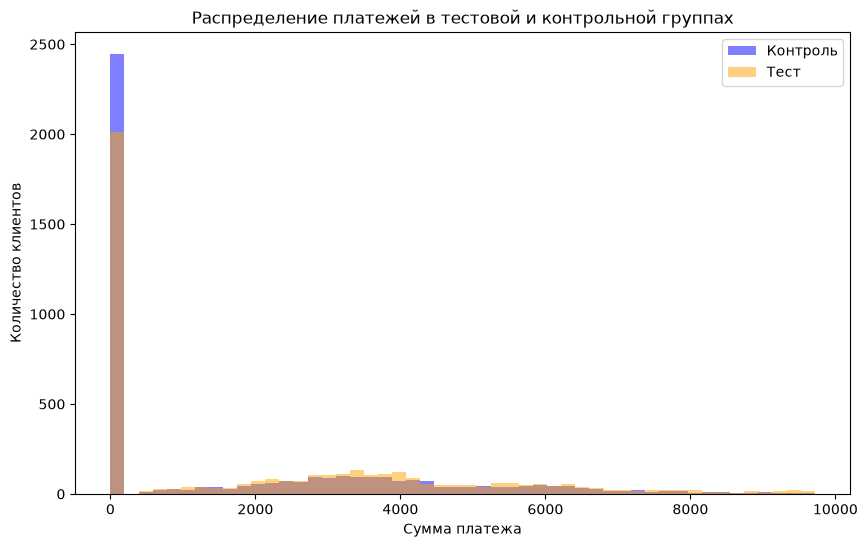

In [53]:
# Гистограмма платежей по Санкт-Петербургу.

# Размер графика
plt.figure(figsize=(10, 6))

# Строим гистограмму для контроля
plt.hist(control_spb['total_payment'], alpha=0.5, label='Контроль', color='blue', bins=50)

# Строим гистограмму для теста поверх контроля
plt.hist(test_spb['total_payment'], alpha=0.5, label='Тест', color='orange', bins=50)

# Оформляем график
plt.title('Распределение платежей в тестовой и контрольной группах')
plt.xlabel('Сумма платежа')
plt.ylabel('Количество клиентов')

# Включаем отображение легенды (окошко с названиями "Контроль" и "Тест")
plt.legend()

# Выводим готовый рисунок на экран
plt.show()

In [54]:
# Применяем функцию test_calc для платежей по Санкт-Петербургу
test_calc(control_spb['total_payment'], test_spb['total_payment'])

T-Statistic: -8.251341635628817
P-Value: 1.7945981505351595e-16
Существует статистически значимая разница между средними.


In [55]:
# Применяем функцию test_calc для конверсии по Санкт-Петербургу
control_conversion_spb = df_clean [(df_clean['nflag_test'] == 0) & (df_clean['city'] =='Санкт-Петербург')]['nflag_payment']
test_conversion_spb = df_clean[(df_clean['nflag_test'] == 1) & (df_clean['city'] =='Санкт-Петербург')]['nflag_payment']
test_calc(control_conversion_spb, test_conversion_spb)

T-Statistic: -8.954160271369426
P-Value: 4.130329641098531e-19
Существует статистически значимая разница между средними.


In [56]:
# Применяем функцию mann_whitney_func для платежей по Санкт-Петербургу
mann_whitney_func(control_spb['total_payment'], test_spb['total_payment'])

Mann-Whitney U Statistic: 8558511.0
P-Value: 4.4381115705489694e-18
Существует статистически значимая разница между средними.


In [57]:
#Проводим тест по всем городам на разницу платежей.
from scipy.stats import ttest_ind

# Получаем список всех уникальных городов
unique_cities = df_clean["city"].unique()

for city in unique_cities:
    # 1. Фильтруем данные для текущего города
    filtered_data = df_clean[df_clean["city"] == city]
    
    # 2. Разделяем целевую метрику (например, "Unit price") на группы А и B
    # Замените "Group" на реальное название вашей колонки с разбивкой А/B
    control = filtered_data[filtered_data["nflag_test"] == 0]["total_payment"]
    test = filtered_data[filtered_data["nflag_test"] == 1]["total_payment"]
    
    print(f"\n--- Анализ для города: {city} ---")
    print(f"Размер группы А: {len(control)}, Размер группы B: {len(test)}")
    
    # Проверка: хватает ли данных в обеих группах для проведения теста
    if len(control) < 2 or len(test) < 2:
        print("Недостаточно данных в одной из групп для проведения t-теста.")
        continue
        
    # 3. Проводим t-тест между группами А и B для выбранной метрики
    t_stat, p_value = ttest_ind(control, test, equal_var=False)
    
    # 4. Выводим результаты
    print(f"t-статистика: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    # Интерпретация
    if p_value < 0.05:
        print("Результат: Различия статистически значимы (p < 0.05)")
    else:
        print("Результат: Различия случайны, статистической значимости нет (p >= 0.05)")

            # Вычисляем скорректированный alpha (поправка Бонферрони)
    alpha_corrected = 0.05 / len(unique_cities)
    
    # Интерпретация с учетом поправки
    if p_value < alpha_corrected:
        print(f"Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < {alpha_corrected:.4f})")
    elif p_value < 0.05:
        print(f"Результат с учетом поправки: Различия значимы локально (p = {p_value:.4f}), но не проходят поправку Бонферрони.")
    else:
        print("Результат с учетом поправки: Различия случайны, статистической значимости нет.")




--- Анализ для города: Красноярск ---
Размер группы А: 2842, Размер группы B: 2969
t-статистика: 0.3429
p-value: 0.7317
Результат: Различия случайны, статистической значимости нет (p >= 0.05)
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Нижний Новгород ---
Размер группы А: 148, Размер группы B: 141
t-статистика: 1.0961
p-value: 0.2740
Результат: Различия случайны, статистической значимости нет (p >= 0.05)
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Мурманск ---
Размер группы А: 1046, Размер группы B: 1039
t-статистика: -0.2637
p-value: 0.7920
Результат: Различия случайны, статистической значимости нет (p >= 0.05)
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Казань ---
Размер группы А: 2433, Размер группы B: 2349
t-статистика: -0.8667
p-value: 0.3862
Результат: Различия случайны, статистической значимости нет (p >

t-статистика: -8.0262
p-value: 0.0000
Результат: Различия статистически значимы (p < 0.05)
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Ярославль ---
Размер группы А: 521, Размер группы B: 557
t-статистика: 20.7966
p-value: 0.0000
Результат: Различия статистически значимы (p < 0.05)
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Саратов ---
Размер группы А: 1084, Размер группы B: 996
t-статистика: -0.2627
p-value: 0.7928
Результат: Различия случайны, статистической значимости нет (p >= 0.05)
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Тольятти ---
Размер группы А: 164, Размер группы B: 183
t-статистика: -1.0373
p-value: 0.3003
Результат: Различия случайны, статистической значимости нет (p >= 0.05)
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для г

 Результаты теста, проведенного по всем городам на разницу платежей
 
--- Анализ для города: Красноярск ---\
Размер группы А: 2842, Размер группы B: 2969\
t-статистика: 0.3429\
p-value: 0.7317\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Нижний Новгород ---\
Размер группы А: 148, Размер группы B: 141\
t-статистика: 1.0961\
p-value: 0.2740\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Мурманск ---\
Размер группы А: 1046, Размер группы B: 1039\
t-статистика: -0.2637\
p-value: 0.7920\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Казань ---\
Размер группы А: 2433, Размер группы B: 2349\
t-статистика: -0.8667\
p-value: 0.3862\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Санкт-Петербург ---\
Размер группы А: 4377, Размер группы B: 4344\
t-статистика: -8.2494\
p-value: 0.0000\
Результат: Различия статистически значимы (p < 0.05)\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Москва ---\
Размер группы А: 6131, Размер группы B: 6009\
t-статистика: -8.0262\
p-value: 0.0000\
Результат: Различия статистически значимы (p < 0.05)\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Ярославль ---\
Размер группы А: 521, Размер группы B: 557\
t-статистика: 20.7966\
p-value: 0.0000\
Результат: Различия статистически значимы (p < 0.05)\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Саратов ---\
Размер группы А: 1084, Размер группы B: 996\
t-статистика: -0.2627\
p-value: 0.7928\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Тольятти ---\
Размер группы А: 164, Размер группы B: 183\
t-статистика: -1.0373\
p-value: 0.3003\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Тюмень ---\
Размер группы А: 141, Размер группы B: 130\
t-статистика: -2.2325\
p-value: 0.0264\
Результат: Различия статистически значимы (p < 0.05)\
Результат с учетом поправки: Различия значимы локально (p = 0.0264), но не проходят поправку Бонферрони.

--- Анализ для города: Волгоград ---\
Размер группы А: 684, Размер группы B: 648\
t-статистика: 1.5811\
p-value: 0.1141\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Сочи ---\
Размер группы А: 789, Размер группы B: 782\
t-статистика: 1.5508\
p-value: 0.1211\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Владимир ---\
Размер группы А: 600, Размер группы B: 491\
t-статистика: -1.5638\
p-value: 0.1182\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Самара ---\
Размер группы А: 838, Размер группы B: 771\
t-статистика: -10.8429\
p-value: 0.0000\
Результат: Различия статистически значимы (p < 0.05)\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Краснодар ---\
Размер группы А: 1105, Размер группы B: 1003\
t-статистика: 1.2996\
p-value: 0.1939\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Сахалинск ---\
Размер группы А: 78, Размер группы B: 73\
t-статистика: -0.9984\
p-value: 0.3198\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Великий Новгород ---\
Размер группы А: 106, Размер группы B: 123\
t-статистика: -0.2241\
p-value: 0.8229\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Дмитров ---\
Размер группы А: 71, Размер группы B: 78\
t-статистика: -0.3329\
p-value: 0.7397\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.


In [58]:
#Проводим тест по всем городам на разницу конверсий в покупку.
from scipy.stats import ttest_ind

# Получаем список всех уникальных городов
unique_cities = df_clean["city"].unique()

for city in unique_cities:
    # 1. Фильтруем данные для текущего города
    filtered_data = df_clean[df_clean["city"] == city]
    
    # 2. Разделяем целевую метрику (например, "Unit price") на группы А и B
    # Замените "Group" на реальное название вашей колонки с разбивкой А/B
    control_conversion = filtered_data[filtered_data["nflag_test"] == 0]["nflag_payment"]
    test_conversion = filtered_data[filtered_data["nflag_test"] == 1]["nflag_payment"]

    
    print(f"\n--- Анализ для города: {city} ---")
    print(f"Размер группы А: {len(control_conversion)}, Размер группы B: {len(test_conversion)}")
    
    # Проверка: хватает ли данных в обеих группах для проведения теста
    if len(control_conversion) < 2 or len(test_conversion) < 2:
        print("Недостаточно данных в одной из групп для проведения t-теста.")
        continue
        
    # 3. Проводим t-тест между группами А и B для выбранной метрики
    t_stat, p_value = ttest_ind(control_conversion, test_conversion, equal_var=False)
    
    # 4. Выводим результаты
    print(f"t-статистика: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    # Интерпретация
    if p_value < 0.05:
        print("Результат: Различия статистически значимы (p < 0.05)")
    else:
        print("Результат: Различия случайны, статистической значимости нет (p >= 0.05)")

            # Вычисляем скорректированный alpha (поправка Бонферрони)
    alpha_corrected = 0.05 / len(unique_cities)
    
    # Интерпретация с учетом поправки
    if p_value < alpha_corrected:
        print(f"Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < {alpha_corrected:.4f})")
    elif p_value < 0.05:
        print(f"Результат с учетом поправки: Различия значимы локально (p = {p_value:.4f}), но не проходят поправку Бонферрони.")
    else:
        print("Результат с учетом поправки: Различия случайны, статистической значимости нет.")




--- Анализ для города: Красноярск ---
Размер группы А: 2842, Размер группы B: 2969
t-статистика: 0.3652
p-value: 0.7150
Результат: Различия случайны, статистической значимости нет (p >= 0.05)
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Нижний Новгород ---
Размер группы А: 148, Размер группы B: 141
t-статистика: 1.4853
p-value: 0.1386
Результат: Различия случайны, статистической значимости нет (p >= 0.05)
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Мурманск ---
Размер группы А: 1046, Размер группы B: 1039
t-статистика: -0.9289
p-value: 0.3531
Результат: Различия случайны, статистической значимости нет (p >= 0.05)
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Казань ---
Размер группы А: 2433, Размер группы B: 2349
t-статистика: -0.0973
p-value: 0.9225
Результат: Различия случайны, статистической значимости нет (p >

 Результаты теста, проведенного по всем городам на конверсий в покупку.

--- Анализ для города: Красноярск ---\
Размер группы А: 2842, Размер группы B: 2969\
t-статистика: 0.3652\
p-value: 0.7150\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Нижний Новгород ---\
Размер группы А: 148, Размер группы B: 141\
t-статистика: 1.4853\
p-value: 0.1386\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Мурманск ---\
Размер группы А: 1046, Размер группы B: 1039\
t-статистика: -0.9289\
p-value: 0.3531\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Казань ---\
Размер группы А: 2433, Размер группы B: 2349\
t-статистика: -0.0973\
p-value: 0.9225\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Санкт-Петербург ---\
Размер группы А: 4377, Размер группы B: 4344\
t-статистика: -8.9540\
p-value: 0.0000\
Результат: Различия статистически значимы (p < 0.05)\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Москва ---\
Размер группы А: 6131, Размер группы B: 6009\
t-статистика: -6.1814\
p-value: 0.0000\
Результат: Различия статистически значимы (p < 0.05)\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Ярославль ---\
Размер группы А: 521, Размер группы B: 557\
t-статистика: 25.0593\
p-value: 0.0000\
Результат: Различия статистически значимы (p < 0.05)\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Саратов ---\
Размер группы А: 1084, Размер группы B: 996\
t-статистика: -0.7713\
p-value: 0.4406\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Тольятти ---\
Размер группы А: 164, Размер группы B: 183\
t-статистика: -1.0470\
p-value: 0.2958\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Тюмень ---\
Размер группы А: 141, Размер группы B: 130\
t-статистика: -2.8201\
p-value: 0.0052\
Результат: Различия статистически значимы (p < 0.05)\
Результат с учетом поправки: Различия значимы локально (p = 0.0052), но не проходят поправку Бонферрони.

--- Анализ для города: Волгоград ---\
Размер группы А: 684, Размер группы B: 648\
t-статистика: 1.4166\
p-value: 0.1568\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Сочи ---\
Размер группы А: 789, Размер группы B: 782\
t-статистика: 1.9357\
p-value: 0.0531\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Владимир ---\
Размер группы А: 600, Размер группы B: 491\
t-статистика: -1.3788\
p-value: 0.1682\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Самара ---\
Размер группы А: 838, Размер группы B: 771\
t-статистика: -11.4268\
p-value: 0.0000\
Результат: Различия статистически значимы (p < 0.05)\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Краснодар ---\
Размер группы А: 1105, Размер группы B: 1003\
t-статистика: 1.7208\
p-value: 0.0854\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Сахалинск ---\
Размер группы А: 78, Размер группы B: 73\
t-статистика: -0.8315\
p-value: 0.4071\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Великий Новгород ---\
Размер группы А: 106, Размер группы B: 123\
t-статистика: 0.4746\
p-value: 0.6355\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Дмитров ---\
Размер группы А: 71, Размер группы B: 78\
t-статистика: -0.3296\
p-value: 0.7421\
Результат: Различия случайны, статистической значимости нет (p >= 0.05)\
Результат с учетом поправки: Различия случайны, статистической значимости нет.


In [59]:
from scipy.stats import mannwhitneyu

# Получаем список всех уникальных городов
unique_cities = df_clean["city"].unique()

# Вычисляем скорректированный alpha (поправка Бонферрони)
# Считаем её ОДИН РАЗ перед циклом, так как количество городов неизменно
alpha_corrected = 0.05 / len(unique_cities)

for city in unique_cities:
    # 1. Фильтруем данные для текущего города
    filtered_data = df_clean[df_clean["city"] == city]

    # 2. Разделяем целевую метрику "total_payment" на группы А и B
    control = filtered_data[filtered_data["nflag_test"] == 0]["total_payment"]
    test = filtered_data[filtered_data["nflag_test"] == 1]["total_payment"]

    print(f"\n--- Анализ для города: {city} ---")
    print(f"Размер группы А: {len(control)}, Размер группы B: {len(test)}")

    # Проверка: хватает ли данных в обеих группах для проведения теста
    if len(control) < 5 or len(test) < 5:
        print(
            "Недостаточно данных в одной из групп для проведения теста Манна-Уитни."
        )
        continue

    # 3. Проводим тест Манна-Уитни между группами А и B
    # alternative="two-sided" проверяет двустороннюю гипотезу (метрика изменилась в любую сторону)
    stat, p_value = mannwhitneyu(control, test, alternative="two-sided")

    # 4. Выводим результаты
    print(f"Mann-Whitney U Statistic: {stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    # Интерпретация с учетом поправки Бонферрони (Глобальный вывод)
    if p_value < alpha_corrected:
        print(
            f"Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < {alpha_corrected:.4f})"
        )
    # Локальная интерпретация (без учета множественного сравнения)
    elif p_value < 0.05:
        print(
            f"Результат с учетом поправки: Различия значимы локально (p = {p_value:.4f}), но не проходят поправку Бонферрони."
        )
    else:
        print(
            "Результат с учетом поправки: Различия случайны, статистической значимости нет."
        )



--- Анализ для города: Красноярск ---
Размер группы А: 2842, Размер группы B: 2969
Mann-Whitney U Statistic: 4239651.5000
p-value: 0.7341
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Нижний Новгород ---
Размер группы А: 148, Размер группы B: 141
Mann-Whitney U Statistic: 11293.0000
p-value: 0.1931
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Мурманск ---
Размер группы А: 1046, Размер группы B: 1039
Mann-Whitney U Statistic: 534195.5000
p-value: 0.4551
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Казань ---
Размер группы А: 2433, Размер группы B: 2349
Mann-Whitney U Statistic: 2829148.0000
p-value: 0.5132
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Санкт-Петербург ---
Размер группы А: 4377, Размер группы B: 4344
Mann-Whitney U Statistic: 8558511.0000
p-valu

Результаты проверки теста в разных городах с помощью теста Манна Уитни на различие среднего чека покупки.

--- Анализ для города: Красноярск ---\
Размер группы А: 2842, Размер группы B: 2969\
Mann-Whitney U Statistic: 4239651.5000\
p-value: 0.7341\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Нижний Новгород ---\
Размер группы А: 148, Размер группы B: 141\
Mann-Whitney U Statistic: 11293.0000\
p-value: 0.1931\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Мурманск ---\
Размер группы А: 1046, Размер группы B: 1039\
Mann-Whitney U Statistic: 534195.5000\
p-value: 0.4551\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Казань ---\
Размер группы А: 2433, Размер группы B: 2349\
Mann-Whitney U Statistic: 2829148.0000\
p-value: 0.5132\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Санкт-Петербург ---\
Размер группы А: 4377, Размер группы B: 4344\
Mann-Whitney U Statistic: 8558511.0000\
p-value: 0.0000\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Москва ---\
Размер группы А: 6131, Размер группы B: 6009\
Mann-Whitney U Statistic: 16970758.0000\
p-value: 0.0000\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Ярославль ---\
Размер группы А: 521, Размер группы B: 557\
Mann-Whitney U Statistic: 224471.0000\
p-value: 0.0000\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Саратов ---\
Размер группы А: 1084, Размер группы B: 996\
Mann-Whitney U Statistic: 532897.5000\
p-value: 0.5977\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Тольятти ---\
Размер группы А: 164, Размер группы B: 183\
Mann-Whitney U Statistic: 14150.5000\
p-value: 0.3438\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Тюмень ---\
Размер группы А: 141, Размер группы B: 130\
Mann-Whitney U Statistic: 7589.0000\
p-value: 0.0070\
Результат с учетом поправки: Различия значимы локально (p = 0.0070), но не проходят поправку Бонферрони.

--- Анализ для города: Волгоград ---\
Размер группы А: 684, Размер группы B: 648\
Mann-Whitney U Statistic: 233388.0000\
p-value: 0.0800\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Сочи ---\
Размер группы А: 789, Размер группы B: 782\
Mann-Whitney U Statistic: 324192.5000\
p-value: 0.0663\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Владимир ---\
Размер группы А: 600, Размер группы B: 491\
Mann-Whitney U Statistic: 139858.0000\
p-value: 0.1261\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Самара ---\
Размер группы А: 838, Размер группы B: 771\
Mann-Whitney U Statistic: 227271.5000\
p-value: 0.0000\
Результат с учетом поправки: Различия статистически значимы с учетом поправки (p < 0.0028)

--- Анализ для города: Краснодар ---\
Размер группы А: 1105, Размер группы B: 1003\
Mann-Whitney U Statistic: 575403.0000\
p-value: 0.1178\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Сахалинск ---\
Размер группы А: 78, Размер группы B: 73\
Mann-Whitney U Statistic: 2690.5000\
p-value: 0.3695\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Великий Новгород ---\
Размер группы А: 106, Размер группы B: 123\
Mann-Whitney U Statistic: 6609.0000\
p-value: 0.8278\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

--- Анализ для города: Дмитров ---\
Размер группы А: 71, Размер группы B: 78\
Mann-Whitney U Statistic: 2722.0000\
p-value: 0.7423\
Результат с учетом поправки: Различия случайны, статистической значимости нет.

 Отчет по A/B-тесту.

In [60]:
df_clean.head()

,id_client,dtime_ad,nflag_test,id_trading_point,total_payment,city,nflag_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,193942,1900-01-01 00:00:00.000,0,13,4144.0,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
5,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0


In [66]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# 1. Считаем общее количество записей во всем датасете
total_records_all = len(df_clean)

# 2. Создаем пустой список для сбора строк будущего датафрейма
report_rows = []

print("Начинаем цикл по городам и точкам...")

# 3. Запускаем цикл по сгруппированным данным
for (city, point), filtered_data in df_clean.groupby(
    ["city", "id_trading_point"]
):

    # Выделяем группы А и B внутри ТТ
    control = filtered_data[filtered_data["nflag_test"] == 0]["total_payment"]
    test = filtered_data[filtered_data["nflag_test"] == 1]["total_payment"]

    # Метрики количества
    count_control = len(control)
    count_test = len(test)
    count_all = len(filtered_data)
    percent_count = (count_all / total_records_all) * 100

    # Проверяем размер групп для проведения теста
    if count_control < 2 or count_test < 2:
        avg_payment_test = test.mean() if count_test > 0 else 0
        avg_payment_control = control.mean() if count_control > 0 else 0
        diff = avg_payment_test - avg_payment_control
        sigma_test = test.std() if count_test > 1 else 0
        sigma_control = control.std() if count_control > 1 else 0
        t_stat, p_value = None, None
        label = "Недостаточно данных"
    else:
        avg_payment_test = test.mean()
        avg_payment_control = control.mean()
        diff = avg_payment_test - avg_payment_control
        sigma_test = test.std()
        sigma_control = control.std()

        # Используем equal_var=False (критерий Уэлча), так как размеры выборок в ТТ могут отличаться
        t_stat, p_value = ttest_ind(control, test, equal_var=False)

        alpha = 0.05  # Порог значимости

        # Логика определения ТРЕХ обязательных лейблов
        if pd.isna(p_value):
            label = "Нейтральный исход"
        elif p_value < alpha:
            # Разница статистически значима
            if diff > 0:
                label = "Положительный исход"
            elif diff < 0:
                label = "Отрицательный исход"
            else:
                label = "Нейтральный исход"
        else:
            # Разницы на самом деле нет (p_value >= alpha)
            label = "Нейтральный исход"

    # Упаковываем строго по требованиям к полям таблицы
    point_results = {
        "city": city,
        "id_trading_point": point,
        "count_test": count_test,
        "count_control": count_control,
        "count_all": count_all,
        "percent_count": percent_count,
        "avg_payment_test": avg_payment_test,
        "avg_payment_control": avg_payment_control,
        "diff": diff,
        "sigma_test": sigma_test,
        "sigma_control": sigma_control,
        "ttest": t_stat,
        "pvalue_ttest": p_value,
        "label": label,  # Колонка-флаг для разделения
    }

    report_rows.append(point_results)

print("Цикл завершен!")

# 4. Создаем итоговый датафрейм из собранного списка строк
df_report = pd.DataFrame(report_rows)
print(f"Создан датафрейм размером: {df_report.shape}")

# 5. Разносим результаты по трем разным листам в зависимости от лейбла
# Фильтруем данные по точным текстовым меткам
df_positive = df_report[df_report["label"] == "Положительный исход"]
df_negative = df_report[df_report["label"] == "Отрицательный исход"]
# Сюда также попадут точки, где различия случайны по p_value
df_neutral = df_report[df_report["label"] == "Нейтральный исход"]

# 6. Выгрузка в Excel с помощью XlsxWriter
excel_filename = "ab_test_report.xlsx"

# Создаем Pandas Excel writer с движком xlsxwriter
with pd.ExcelWriter(excel_filename, engine="xlsxwriter") as writer:
    # Записываем каждый датафрейм на свой лист
    df_positive.to_excel(writer, sheet_name="Положительный исход", index=False)
    df_negative.to_excel(writer, sheet_name="Отрицательный исход", index=False)
    df_neutral.to_excel(writer, sheet_name="Нейтральный исход", index=False)

    # Дополнительно: выгрузим строки с недостатком данных на отдельный лист, чтобы не потерять
    df_no_data = df_report[df_report["label"] == "Недостаточно данных"]
    if not df_no_data.empty:
        df_no_data.to_excel(writer, sheet_name="Недостаточно данных", index=False)

print(f"\nРезультаты успешно выгружены в файл: {excel_filename}")
print(f"Строк в 'Положительный исход': {len(df_positive)}")
print(f"Строк в 'Отрицательный исход': {len(df_negative)}")
print(f"Строк в 'Нейтральный исход': {len(df_neutral)}")


Начинаем цикл по городам и точкам...
Цикл завершен!
Создан датафрейм размером: (54, 14)

Результаты успешно выгружены в файл: ab_test_report.xlsx
Строк в 'Положительный исход': 16
Строк в 'Отрицательный исход': 1
Строк в 'Нейтральный исход': 37
